In [70]:
import tensorflow as tf
import matplotlib.dates as mdates
from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
import re
from sklearn.utils import class_weight
import matplotlib.pyplot as plt
import numpy as np
from itertools import cycle
from sklearn.metrics import confusion_matrix, precision_recall_curve, roc_curve, auc, classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import learning_curve, train_test_split
from sklearn.preprocessing import label_binarize

In [12]:
# Load the dataset
data = pd.read_csv('e8.csv')

def preprocess_comments(comment, label):
    if label == 'Engagement':
        comment = '<engagement> ' + comment
    elif label == 'Query' and (re.search(r'\?', comment) or any(word.lower() in comment for word in ['what', 'where', 'when', 'how'])):
        comment = '<query> ' + comment
    return comment

data['Comment'] = data.apply(lambda row: preprocess_comments(row['Comment'], row['Label']), axis=1)

In [13]:
# Preprocess the data
tokenizer = Tokenizer()
tokenizer.fit_on_texts(data['Comment'])
sequences = tokenizer.texts_to_sequences(data['Comment'])
max_len = max([len(seq) for seq in sequences])
X = pad_sequences(sequences, maxlen=max_len)
y = pd.get_dummies(data['Label']).values

# Split the data into train, validation, and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [14]:
# Define the LSTM model
vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 100

model = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=max_len),
    SpatialDropout1D(0.7),
    Bidirectional(LSTM(128, dropout=0.7, recurrent_dropout=0.7, kernel_regularizer=l2(0.001))),
    Dense(5, activation='softmax')
])

In [15]:
# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Early stopping callback
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history=model.fit(X_train, y_train, epochs=30, batch_size=64, validation_data=(X_val, y_val), callbacks=[early_stop])

Epoch 1/30
299/299 [==============================] - 892s 3s/step - loss: 1.6031 - accuracy: 0.3037 - val_loss: 1.2453 - val_accuracy: 0.4861
Epoch 2/30
299/299 [==============================] - 850s 3s/step - loss: 1.7224 - accuracy: 0.2238 - val_loss: 1.6698 - val_accuracy: 0.2206
Epoch 3/30
299/299 [==============================] - 847s 3s/step - loss: 1.6574 - accuracy: 0.2463 - val_loss: 1.6318 - val_accuracy: 0.3685
Epoch 4/30
299/299 [==============================] - 845s 3s/step - loss: 1.5280 - accuracy: 0.3521 - val_loss: 1.2342 - val_accuracy: 0.4988
Epoch 5/30
299/299 [==============================] - 848s 3s/step - loss: 1.1120 - accuracy: 0.5147 - val_loss: 0.9278 - val_accuracy: 0.5912
Epoch 6/30
299/299 [==============================] - 846s 3s/step - loss: 0.9436 - accuracy: 0.6167 - val_loss: 0.7055 - val_accuracy: 0.7079
Epoch 7/30
299/299 [==============================] - 831s 3s/step - loss: 0.8269 - accuracy: 0.6895 - val_loss: 0.6771 - val_accuracy: 0.7446

In [60]:
model.save('ProtoFinal.h5')

/home/alienblade/College Stuff/Workspace/.venv/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [16]:
# Evaluate the model
score = model.evaluate(X_test, y_test, verbose=0)
print('Test accuracy:', score[1])

Test accuracy: 0.8771371245384216


In [17]:
# Get the training and validation accuracy and loss values
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']

In [37]:
# Evaluate the model on the test set
y_pred = model.predict(X_val)
y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_val, axis=1)

150/150 [==============================] - 49s 325ms/step


In [64]:
class_names=['Appreciation', 'Criticism', 'Engagement', 'Neutral', 'Query']
# Generate the classification report
print('Classification Report:')
print(classification_report(y_true, y_pred, target_names=class_names))

# Calculate additional metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f'\nAccuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')

Classification Report:
              precision    recall  f1-score   support

Appreciation       0.81      0.81      0.81       954
   Criticism       0.77      0.82      0.79       955
  Engagement       1.00      1.00      1.00       918
     Neutral       0.81      0.76      0.78       965
       Query       1.00      1.00      1.00       981

    accuracy                           0.88      4773
   macro avg       0.88      0.88      0.88      4773
weighted avg       0.88      0.88      0.88      4773


Accuracy: 0.8760
Precision: 0.8764
Recall: 0.8760
F1-Score: 0.8759


In [66]:
class_names = ['Appreciation', 'Criticism', 'Engagement', 'Neutral', 'Query']

# Print a few examples of predicted and true labels
print("Examples of predicted and true labels:")
for i in range(10):  # Print the first 10 examples
    true_label = class_names[y_true[i]]
    pred_label = class_names[y_pred[i]]
    print(f"True label: {true_label}, Predicted label: {pred_label}")

Examples of predicted and true labels:
True label: Criticism, Predicted label: Criticism
True label: Engagement, Predicted label: Engagement
True label: Neutral, Predicted label: Criticism
True label: Engagement, Predicted label: Engagement
True label: Appreciation, Predicted label: Neutral
True label: Query, Predicted label: Query
True label: Query, Predicted label: Query
True label: Engagement, Predicted label: Engagement
True label: Appreciation, Predicted label: Appreciation
True label: Criticism, Predicted label: Criticism


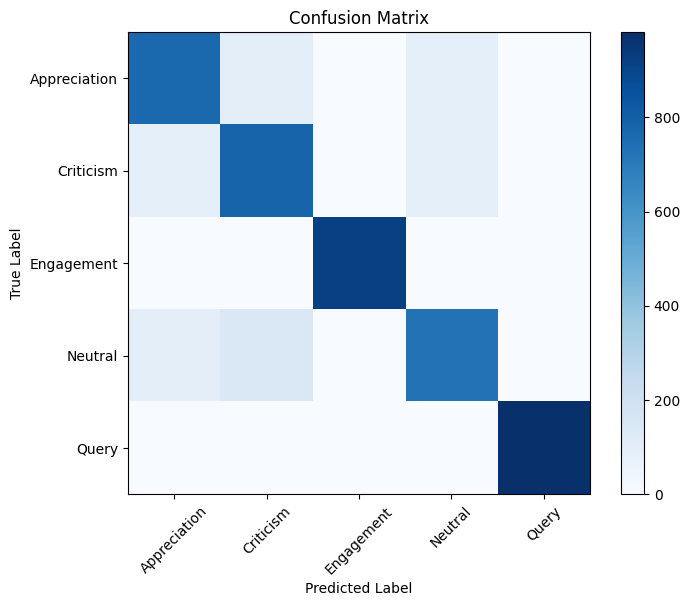

In [67]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap='Blues', interpolation='nearest')
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [50]:
print(y_pred)

[1 2 1 ... 3 4 2]


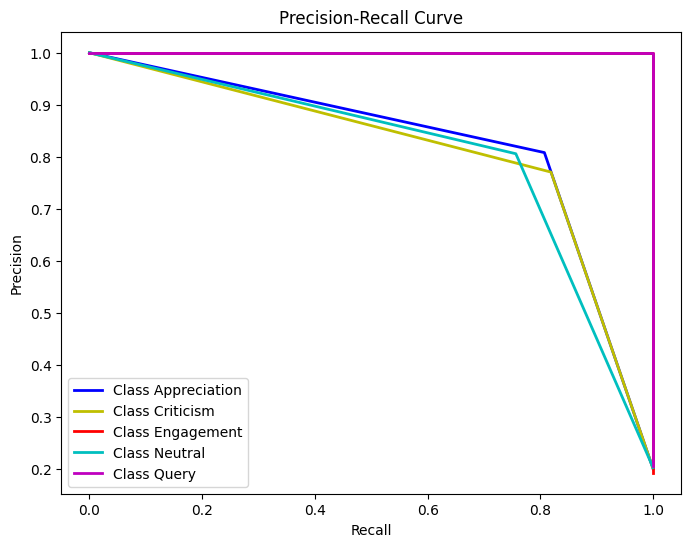

In [68]:
# Precision-Recall Curve
plt.figure(figsize=(8, 6))
colors = cycle('byrcmgk')

# Binarize the true labels and predicted labels
y_true_bin = label_binarize(y_true, classes=list(range(len(class_names))))
y_pred_bin = label_binarize(y_pred, classes=list(range(len(class_names))))

for i, color in zip(range(len(class_names)), colors):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_pred_bin[:, i])
    plt.plot(recall, precision, color=color, lw=2, label=f'Class {class_names[i]}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='best')
plt.show()

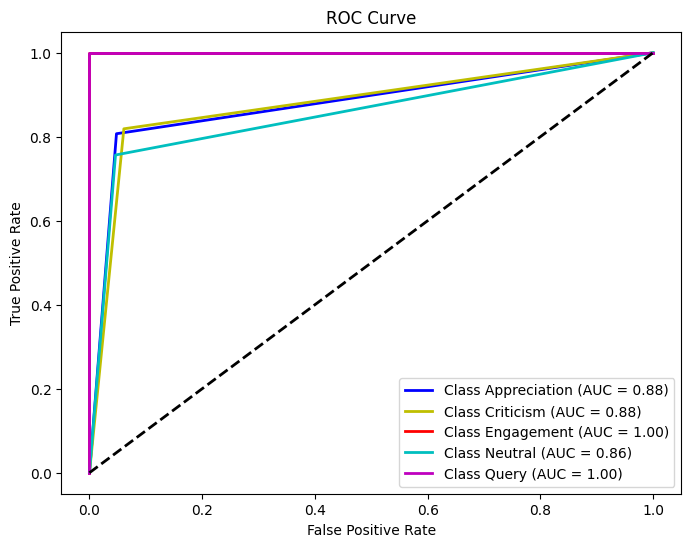

In [69]:
# ROC Curve
plt.figure(figsize=(8, 6))
colors = cycle('byrcmgk')

# Binarize the true labels and predicted labels
y_true_bin = label_binarize(y_true, classes=list(range(len(class_names))))
y_pred_bin = label_binarize(y_pred, classes=list(range(len(class_names))))

for i, color in zip(range(len(class_names)), colors):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_bin[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'Class {class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='best')
plt.show()



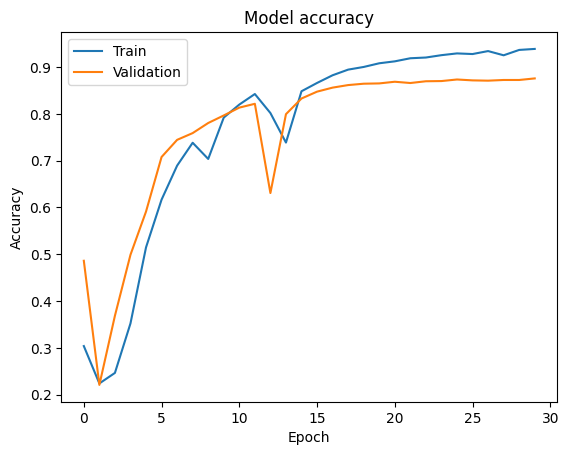

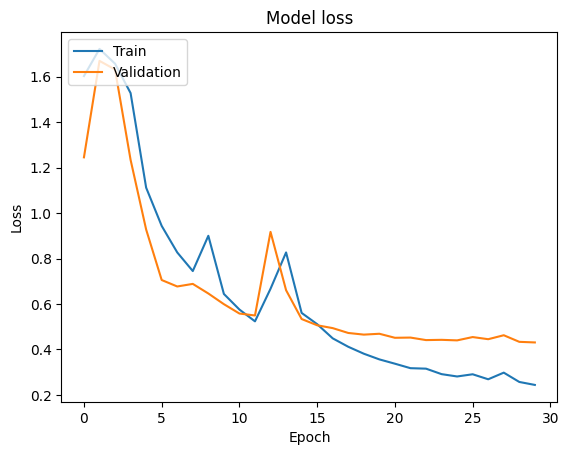

In [56]:
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


In [58]:
# Predict probabilities for the test set
y_pred_prob = model.predict(X_test)

# Compute ROC curve and ROC area for each class
fpr, tpr, _ = roc_curve(y_test[:, 1], y_pred_prob[:, 1])
roc_auc = auc(fpr, tpr)

# Compute Precision-Recall curve and area for each class
precision, recall, _ = precision_recall_curve(y_test[:, 1], y_pred_prob[:, 1])
pr_auc = auc(recall, precision)


187/187 [==============================] - 56s 302ms/step


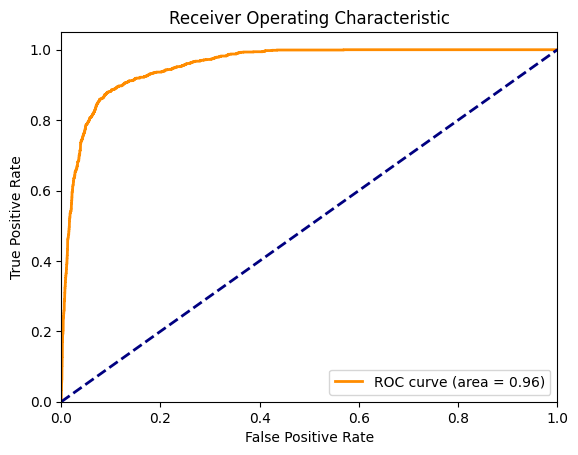

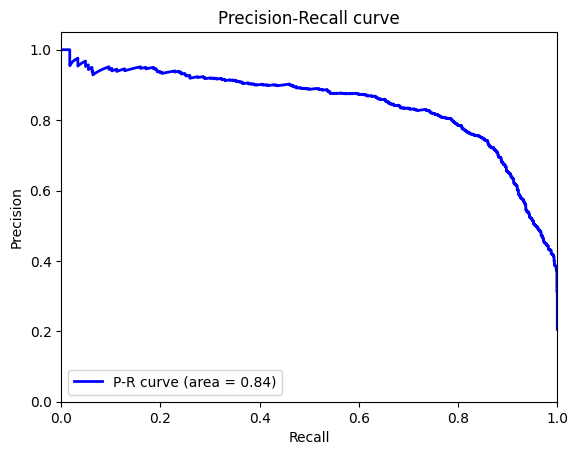

In [59]:
# Plot Precision-Recall curve
plt.figure()
plt.plot(recall, precision, color='blue', lw=2, label='P-R curve (area = %0.2f)' % pr_auc)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curve')
plt.legend(loc="lower left")
plt.show()

In [79]:
# Read the CSV file
df = pd.read_csv('t2.csv')

# Parse the timestamps
df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%M:%S')

# Group by the timestamps within a 5-second window and count occurrences
grouped = df.groupby(pd.Grouper(key='Timestamp', freq='5s')).size()

In [80]:
# Find the most common timestamp
most_common_timestamp = grouped.idxmax()

# Extract the time part of the most common timestamp
most_common_time = most_common_timestamp.time()

# Filter the data to include only the most common timestamp
filtered_data = df[(df['Timestamp'] >= most_common_timestamp - pd.Timedelta(seconds=5)) &
                    (df['Timestamp'] <= most_common_timestamp + pd.Timedelta(seconds=5))]

# Group by labels and count occurrences
label_counts = filtered_data['Label'].value_counts()

# Rank labels based on occurrence counts
ranked_labels = label_counts.index.tolist()

# Print the most common timestamp and ranked labels
print(f"Most common timestamp: {most_common_time}")
print("Ranked labels:")
for rank, label in enumerate(ranked_labels, start=1):
    print(f"{rank}. {label}: {label_counts[label]} occurrences")

Most common timestamp: 00:06:45
Ranked labels:
1. Neutral: 347 occurrences
2. Appreciation: 95 occurrences
3. Criticism: 86 occurrences
4. Query: 26 occurrences


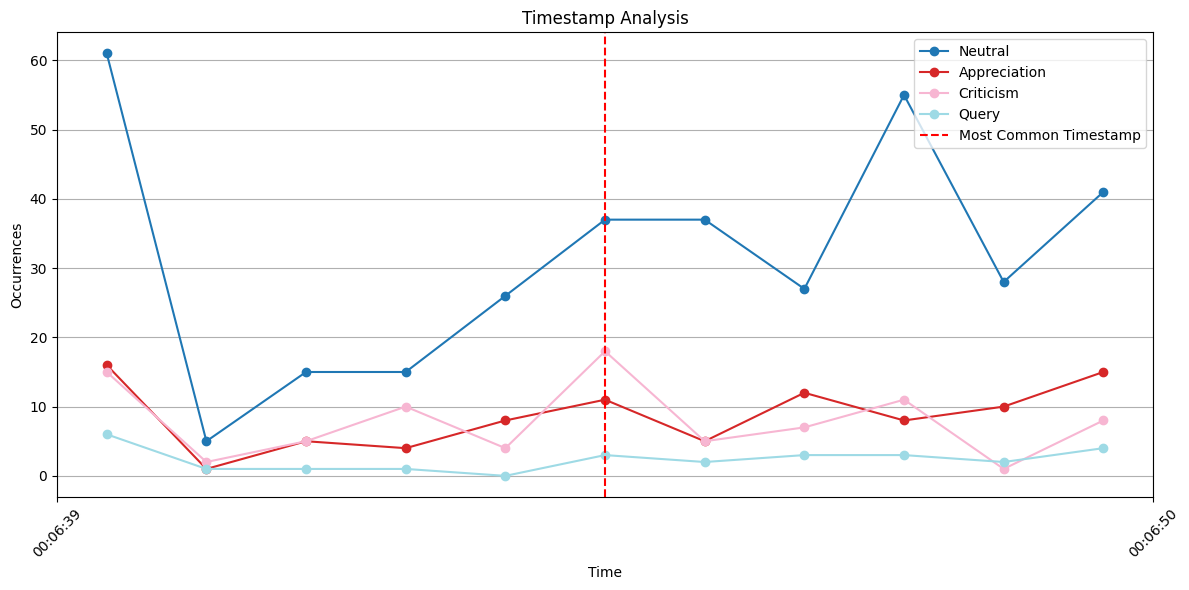

At 00:06:45, the most common label is Neutral


In [81]:
# Plot the timeline with most common timestamp prominently
plt.figure(figsize=(12, 6))
colors = plt.cm.tab20(np.linspace(0, 1, len(ranked_labels)))  # Generate a list of colors
for label, color in zip(ranked_labels, colors):
    label_data = filtered_data[filtered_data['Label'] == label]
    label_grouped = label_data.groupby(pd.Grouper(key='Timestamp', freq='1s')).size()
    plt.plot(label_grouped.index, label_grouped.values, marker='o', label=label, color=color)
plt.axvline(x=most_common_timestamp, color='red', linestyle='--', label='Most Common Timestamp')
plt.xlabel('Time')
plt.ylabel('Occurrences')
plt.title('Timestamp Analysis')
plt.legend()
plt.grid(True)
plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(interval=3))  # Set interval for x-axis ticks
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))  # Format x-axis ticks as HH:MM:SS
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print(f"At {most_common_time}, the most common label is {ranked_labels[0]}")